# VI vs MCMC
## 2. MCMC — No-U-Turn Sampler (NUTS)

В этой части мы применим марковский метод Монте-Карло (MCMC) в виде алгоритма **NUTS** к той же задаче кластеризации смеси гауссиан. В отличие от VI, MCMC асимптотически точен — при достаточном числе шагов цепи он сходится к истинному апостериорному распределению $p(\theta \mid x)$.

### Что будем делать
- Определим **полную** модель GMM с матрицей ковариации через разложение Холецкого (`LKJCholesky`)
- Запустим NUTS с двумя разными вариантами прогрева: `warmup_steps=20` и `warmup_steps=100`
- Проанализируем диагностику: **Trace Plots**, **R-hat**, **Autocorrelation Plot**
- Построим 2-sigma эллипсы рассеивания поверх данных
- Сравним время работы с VI

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import time

import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS


### Генерация данных

Используем те же данные, что и в части 1.1 — три кластера: **A** (широкий изотропный), **B** (вытянутый по диагонали), **C** (узкий пик рядом с B).

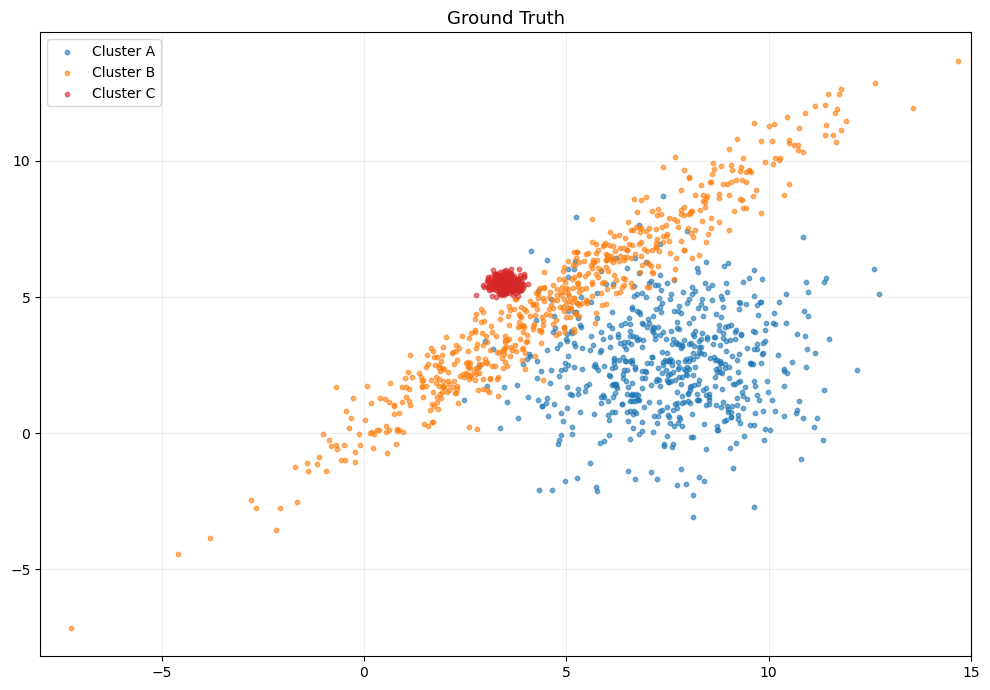

In [3]:
def generate_complex_gmm_data_with_labels(n_samples=1500):
    torch.manual_seed(42)

    # Кластер A: Широкий (n=600)
    loc_a = torch.tensor([7.5, 2.5])
    data_a = torch.randn(600, 2) * 1.8 + loc_a
    labels_a = torch.zeros(600)

    # Кластер B: Вытянутый по диагонали (n=600)
    loc_b = torch.tensor([5.0, 5.0])
    scale_b = torch.tensor([4.5, 0.6])
    theta = torch.tensor([torch.pi / 4])  # 45 градусов
    rot = torch.tensor([[theta.cos(), -theta.sin()],
                        [theta.sin(),  theta.cos()]])
    data_b = (torch.randn(600, 2) * scale_b) @ rot.T + loc_b
    labels_b = torch.ones(600)

    # Кластер C: Узкий пик рядом с B (n=300)
    loc_c = torch.tensor([3.5, 5.5])
    data_c = torch.randn(300, 2) * 0.2 + loc_c
    labels_c = torch.ones(300) * 2

    data   = torch.cat([data_a, data_b, data_c])
    labels = torch.cat([labels_a, labels_b, labels_c])
    idx = torch.randperm(n_samples)
    return data[idx], labels[idx]


data_2d, true_labels = generate_complex_gmm_data_with_labels()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#d62728']
for i, lbl in enumerate(['A', 'B', 'C']):
    mask = (true_labels == i)
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
               s=10, alpha=0.6, c=colors[i], label=f'Cluster {lbl}')
ax.set_title('Ground Truth', fontsize=13)
ax.legend()
ax.set_xlim(-8, 15)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Модель GMM с полной матрицей ковариации

Для корректного захвата диагонального кластера **B** переходим от диагональной к **полной** матрице ковариации. Используем разложение Холецкого

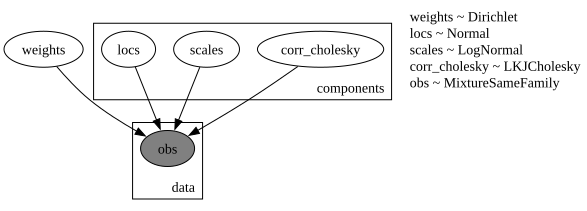

In [4]:
def model_full_cov(data, K=3):
    """
    GMM с полной матрицей ковариации (через LKJCholesky).
    Подходит для NUTS: все трансформации дифференцируемы,
    P.D. гарантирована конструкцией.
    """
    D = data.shape[1]

    # Веса кластеров: Dirichlet(1) = равномерное априорное
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))

    with pyro.plate("components", K):
        # Центры кластеров
        locs = pyro.sample(
            "locs",
            dist.Normal(torch.zeros(D), 5.0).to_event(1)   # слабый prior
        )
        # Масштабы (стандартные отклонения по осям)
        scales = pyro.sample(
            "scales",
            dist.LogNormal(torch.zeros(D), 1.0).to_event(1)
        )
        # Корреляционная матрица Холецкого
        # LKJCholesky(concentration=1) = равномерное на корреляционных матрицах
        corr_cholesky = pyro.sample(
            "corr_cholesky",
            dist.LKJCholesky(D, concentration=1.0)
        )

        # Полная матрица Холецкого: L = diag(scales) @ corr_cholesky
        L = torch.matmul(torch.diag_embed(scales), corr_cholesky)

    # Собираем смесь
    mixing_dist    = dist.Categorical(weights)
    component_dist = dist.MultivariateNormal(locs, scale_tril=L)
    mixture        = dist.MixtureSameFamily(mixing_dist, component_dist)

    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)


# Визуализация графа модели
pyro.render_model(
    model_full_cov,
    model_args=(data_2d,),
    render_distributions=True
)

### Вспомогательные функции визуализации

In [9]:
def cov_from_samples(locs_s, scales_s, corr_chol_s):
    """
    Из сэмплов MCMC вычисляет posterior mean для:
      - центров кластеров
      - полных матриц ковариации
      - весов
    
    locs_s:       (S, K, D)
    scales_s:     (S, K, D)
    corr_chol_s:  (S, K, D, D)
    """
    S, K, D = locs_s.shape

    mean_locs = locs_s.mean(0)   # (K, D)

    covs = []
    for k in range(K):
        # Для каждого сэмпла: L = diag(scales) 
        sc = scales_s[:, k, :]       # (S, D)
        ch = corr_chol_s[:, k, :, :] # (S, D, D)
        L  = torch.diag_embed(sc) @ ch  # (S, D, D)
        Sigma = L @ L.transpose(-1, -2)  # (S, D, D)
        covs.append(Sigma.mean(0))       # (D, D)

    return mean_locs, covs


def plot_full_cov_ellipses(ax, locs, covs, weights, color, alpha=0.9, label_prefix=''):
    """
    Рисует 2-sigma эллипсы для полной матрицы ковариации.
    
    locs:    (K, 2)
    covs:    list of K tensors (2, 2)
    weights: (K,)
    """
    K = len(covs)
    for k in range(K):
        mu  = locs[k].numpy() if torch.is_tensor(locs[k]) else locs[k]
        Sig = covs[k].numpy()  if torch.is_tensor(covs[k]) else covs[k]
        w   = weights[k].item() if torch.is_tensor(weights[k]) else weights[k]

        # Собственные числа и векторы для угла и полуосей
        eigvals, eigvecs = np.linalg.eigh(Sig)
        eigvals = np.maximum(eigvals, 1e-8)  # численная стабильность

        # Угол главной оси эллипса
        angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
        # 2-sigma: полуоси = 2 * sqrt(eigenvalue)
        width  = 4 * np.sqrt(eigvals[1])
        height = 4 * np.sqrt(eigvals[0])

        # Заливка
        ell_fill = patches.Ellipse(
            xy=mu, width=width, height=height, angle=angle,
            edgecolor=color, facecolor=color, alpha=0.12, linewidth=2
        )
        ax.add_patch(ell_fill)
        # Контур
        ell_edge = patches.Ellipse(
            xy=mu, width=width, height=height, angle=angle,
            edgecolor=color, facecolor='none', linewidth=2, alpha=alpha
        )
        ax.add_patch(ell_edge)
        # Центр
        ax.scatter(*mu, s=60, marker='+', color=color, zorder=5, linewidths=2)
        # Подпись
        ax.annotate(f'{label_prefix}k{k+1} w={w:.2f}',
                    xy=mu, fontsize=8, ha='center', va='bottom',
                    color=color, fontweight='bold')

---
## Часть 1: NUTS с warmup_steps = 20

Короткий прогрев означает, что NUTS не успевает настроить свои гиперпараметры (размер шага $\varepsilon$ и метрику масс). Цепь может работать неэффективно — принимать слишком маленькие или слишком большие шаги.

In [8]:
NUM_SAMPLES = 300
NUM_CHAINS  = 1     
K           = 3

# ---------- warmup = 20 ----------
pyro.clear_param_store()
torch.manual_seed(42)

nuts_kernel_20 = NUTS(
    model_full_cov,
    adapt_step_size=True,
    target_accept_prob=0.8,
    jit_compile=False
)

mcmc_20 = MCMC(
    nuts_kernel_20,
    num_samples=NUM_SAMPLES,
    warmup_steps=20,
    num_chains=NUM_CHAINS,
    disable_progbar=False
)

t0 = time.time()
mcmc_20.run(data_2d)
time_20 = time.time() - t0

print(f"\nВремя (warmup=20):  {time_20:.1f}s")
samples_20 = mcmc_20.get_samples()
print("Форма сэмплов 'locs':", samples_20['locs'].shape)   # (S, K, D)

Sample: 100%|█████████████████████████████████████████| 320/320 [00:39,  8.14it/s, step size=3.43e-02, acc. prob=0.104]



Время (warmup=20):  39.3s
Форма сэмплов 'locs': torch.Size([300, 3, 2])


---
## Часть 2: NUTS с warmup_steps = 100

Более длинный прогрев позволяет NUTS лучше откалибровать шаг и метрику. Ожидаем более эффективное исследование пространства параметров и лучшее перемешивание цепи.

In [12]:
# ---------- warmup = 100 ----------
pyro.clear_param_store()
torch.manual_seed(42)

nuts_kernel_100 = NUTS(
    model_full_cov,
    adapt_step_size=True,
    target_accept_prob=0.8,
    jit_compile=False
)

mcmc_100 = MCMC(
    nuts_kernel_100,
    num_samples=NUM_SAMPLES,
    warmup_steps=100,
    num_chains=NUM_CHAINS,
    disable_progbar=False
)

t0 = time.time()
mcmc_100.run(data_2d)
time_100 = time.time() - t0

print(f"\nВремя (warmup=100): {time_100:.1f}s")
samples_100 = mcmc_100.get_samples()
print("Форма сэмплов 'locs':", samples_100['locs'].shape)

Sample: 100%|█████████████████████████████████████████| 400/400 [11:21,  1.70s/it, step size=4.80e-03, acc. prob=0.969]


Время (warmup=100): 681.2s
Форма сэмплов 'locs': torch.Size([300, 3, 2])


---
## Диагностика: Trace Plots

**Trace plot** показывает значения параметра по итерациям цепи. Хорошо перемешавшаяся цепь выглядит как "мохнатая гусеница" — быстрые осцилляции без дрейфа или застревания.

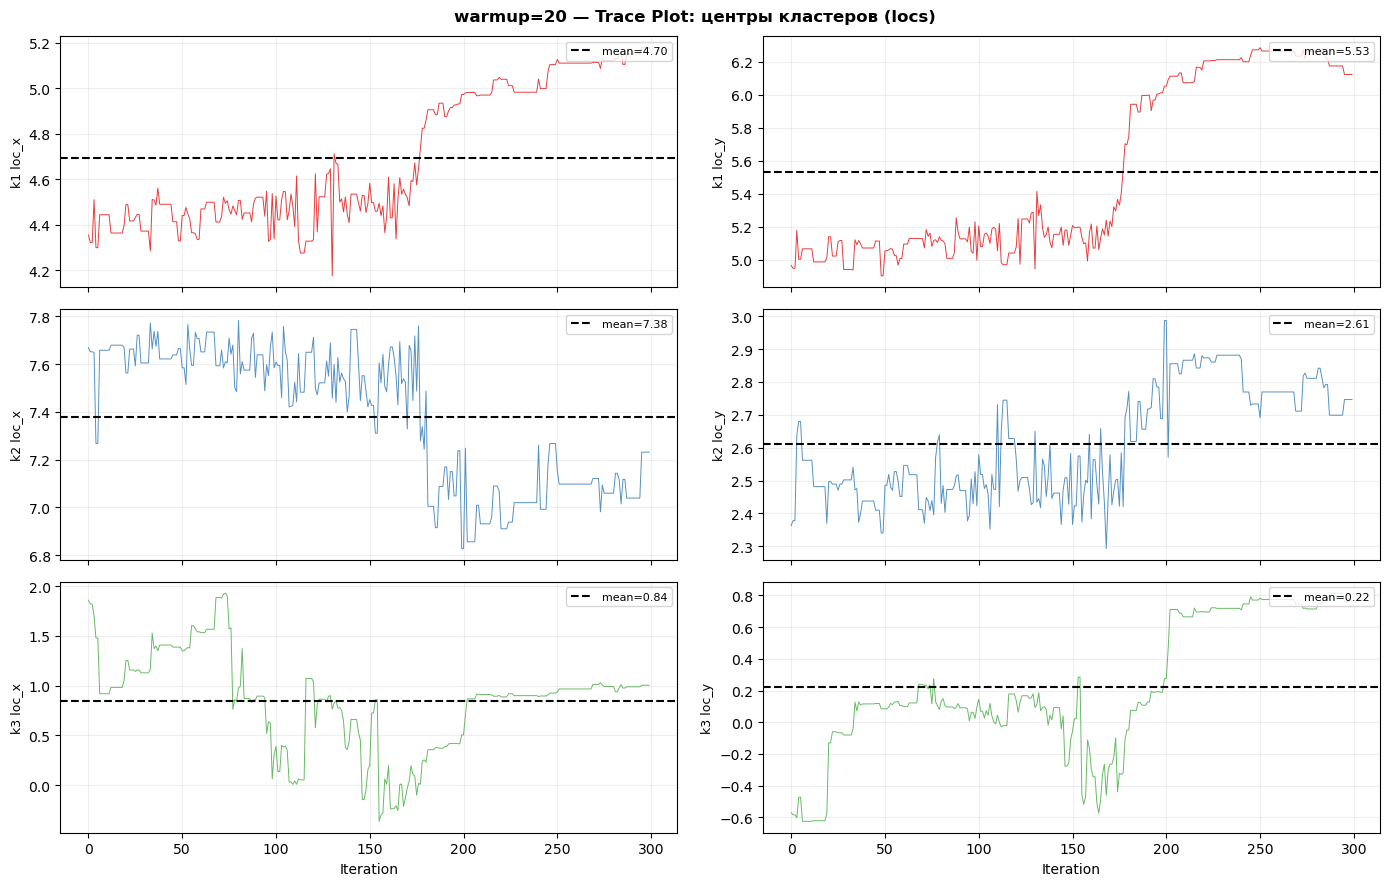

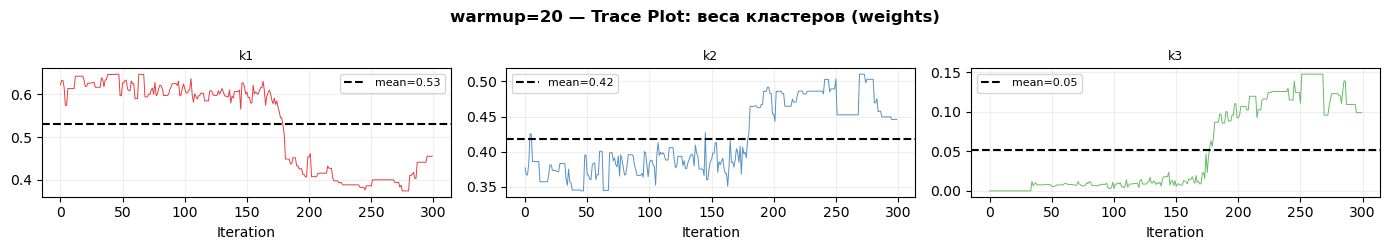

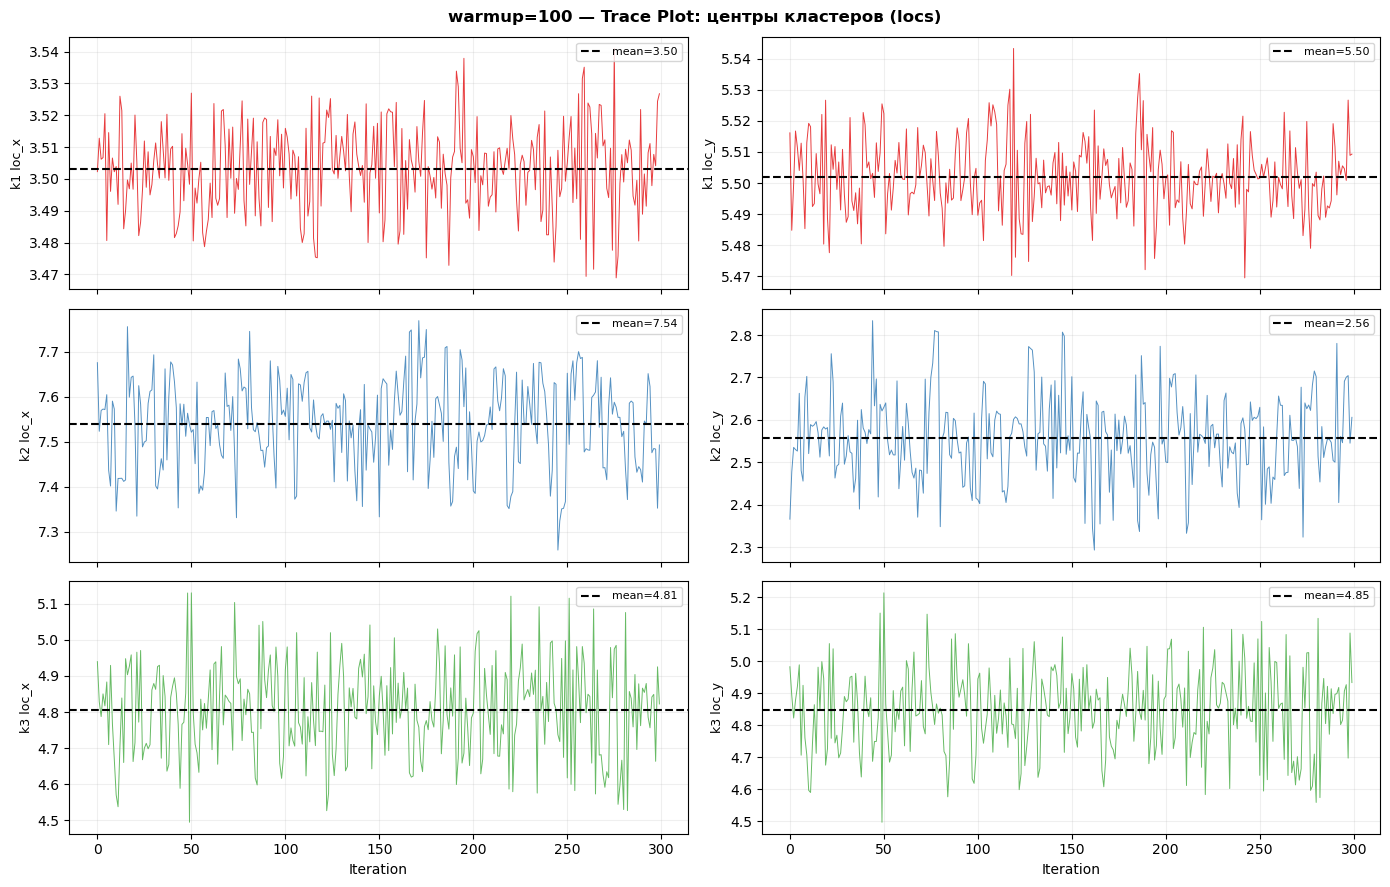

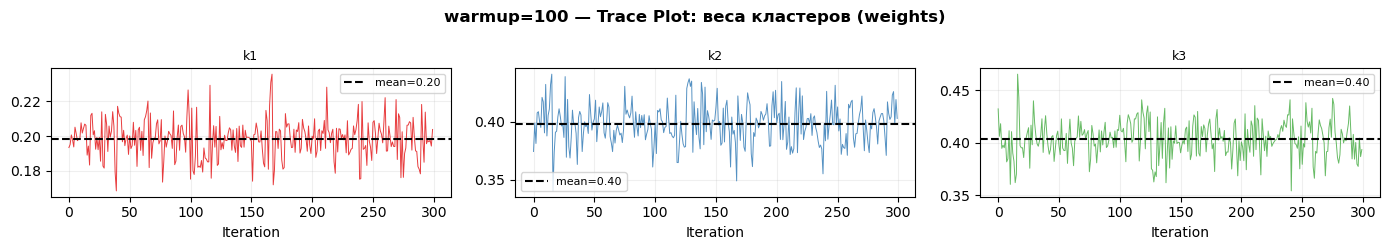

In [19]:
def plot_trace_plots(samples_dict, title_prefix, n_components=3, dim=2):
    """
    Строит trace plots для locs и scales всех K компонентов.
    """
    locs_s   = samples_dict['locs']    # (S, K, D)
    scales_s = samples_dict['scales']  # (S, K, D)
    weights_s = samples_dict['weights'] # (S, K)
    S = locs_s.shape[0]
    steps = np.arange(S)

    comp_colors = ['#e41a1c', '#377eb8', '#4daf4a']
    coord_names = ['x', 'y']

    # --- locs trace ---
    fig, axes = plt.subplots(n_components, dim, figsize=(14, 3 * n_components),
                             sharex=True)
    fig.suptitle(f'{title_prefix} — Trace Plot: центры кластеров (locs)',
                 fontsize=12, fontweight='bold')

    for k in range(n_components):
        for d in range(dim):
            ax = axes[k, d]
            ax.plot(steps, locs_s[:, k, d].numpy(),
                    color=comp_colors[k], lw=0.7, alpha=0.85)
            ax.axhline(locs_s[:, k, d].mean().item(), color='black',
                       lw=1.5, ls='--', label=f'mean={locs_s[:, k, d].mean():.2f}')
            ax.set_ylabel(f'k{k+1} loc_{coord_names[d]}', fontsize=9)
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(True, alpha=0.2)

    axes[-1, 0].set_xlabel('Iteration')
    axes[-1, 1].set_xlabel('Iteration')
    plt.tight_layout()
    plt.show()

    # --- weights trace ---
    fig, axes = plt.subplots(1, n_components, figsize=(14, 2.5), sharex=True)
    fig.suptitle(f'{title_prefix} — Trace Plot: веса кластеров (weights)',
                 fontsize=12, fontweight='bold')
    for k in range(n_components):
        axes[k].plot(steps, weights_s[:, k].numpy(),
                     color=comp_colors[k], lw=0.7, alpha=0.85)
        axes[k].axhline(weights_s[:, k].mean().item(), color='black',
                        lw=1.5, ls='--',
                        label=f'mean={weights_s[:, k].mean():.2f}')
        axes[k].set_title(f'k{k+1}', fontsize=9)
        axes[k].set_xlabel('Iteration')
        axes[k].legend(fontsize=8)
        axes[k].grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


plot_trace_plots(samples_20,  'warmup=20')
plot_trace_plots(samples_100, 'warmup=100')

---
## Диагностика: Autocorrelation Plot


**Автокорреляция** показывает, насколько коррелированы соседние сэмплы в цепи. Идеальная цепь — нулевая автокорреляция при любом лаге > 0. Высокая автокорреляция означает медленное перемешивание и малый **ESS** (effective sample size).



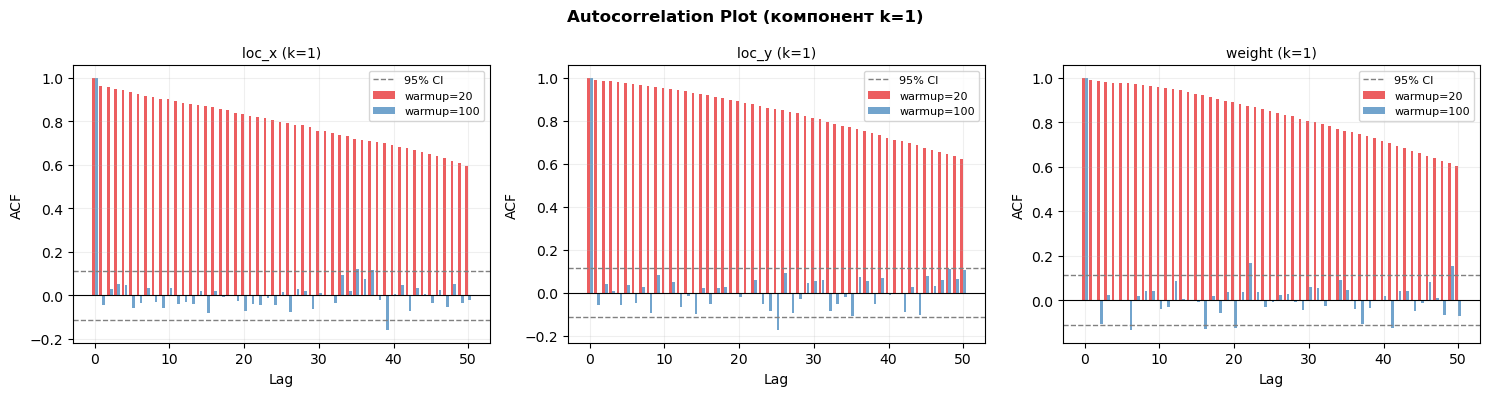

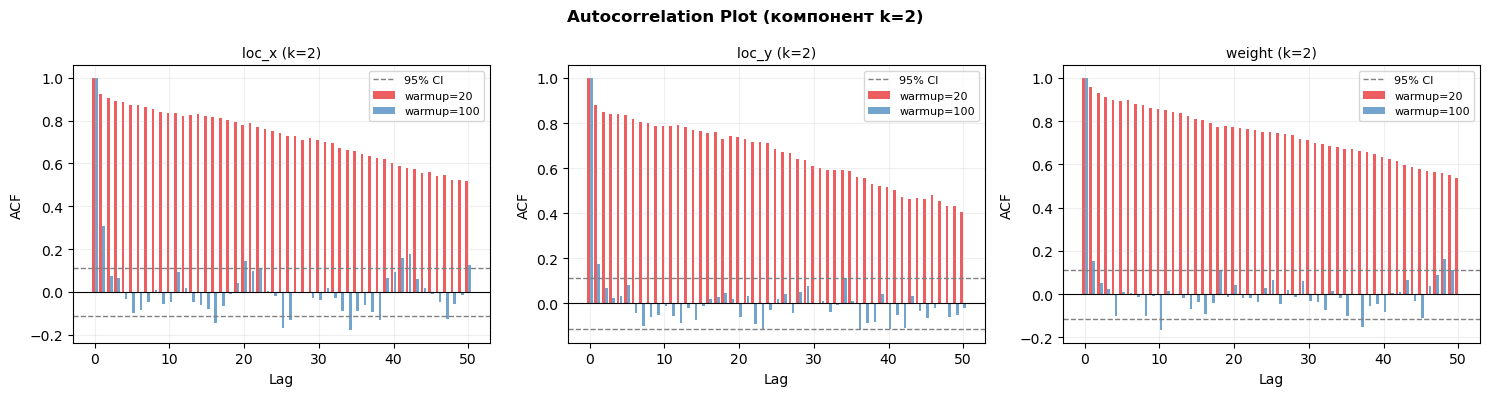

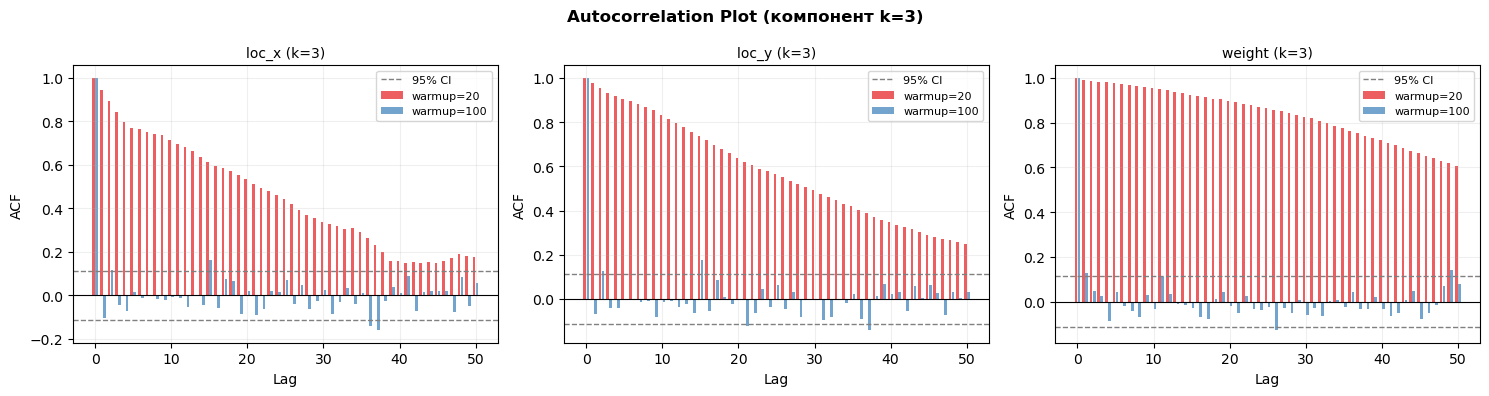

In [14]:
def autocorr(x, max_lag=50):
    """Вычисляет автокорреляцию ряда x для лагов 0..max_lag."""
    x = x - x.mean()
    var = (x ** 2).mean()
    if var < 1e-10:
        return np.zeros(max_lag + 1)
    acf = []
    for lag in range(max_lag + 1):
        if lag == 0:
            acf.append(1.0)
        else:
            acf.append(((x[:-lag] * x[lag:]).mean() / var).item())
    return np.array(acf)


def plot_autocorrelation(samples_20, samples_100, max_lag=50, k=0):
    """
    Строит ACF для loc_x компонента k при обоих вариантах прогрева.
    """
    lags = np.arange(max_lag + 1)
    params_to_plot = [
        ('locs',    (k, 0), f'loc_x (k={k+1})'),
        ('locs',    (k, 1), f'loc_y (k={k+1})'),
        ('weights', (k,),   f'weight (k={k+1})'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Autocorrelation Plot (компонент k={k+1})',
                 fontsize=12, fontweight='bold')

    for ax, (key, idx, label) in zip(axes, params_to_plot):
        s20  = samples_20[key][:, idx[0]] if len(idx) == 1 else samples_20[key][:, idx[0], idx[1]]
        s100 = samples_100[key][:, idx[0]] if len(idx) == 1 else samples_100[key][:, idx[0], idx[1]]

        acf20  = autocorr(s20.numpy(),  max_lag)
        acf100 = autocorr(s100.numpy(), max_lag)

        ax.bar(lags - 0.2, acf20,  width=0.35, color='#e41a1c', alpha=0.7,
               label='warmup=20')
        ax.bar(lags + 0.2, acf100, width=0.35, color='#377eb8', alpha=0.7,
               label='warmup=100')
        ax.axhline(0, color='black', lw=0.8)
        ax.axhline( 1.96 / np.sqrt(NUM_SAMPLES), color='grey', lw=1, ls='--',
                    label='95% CI')
        ax.axhline(-1.96 / np.sqrt(NUM_SAMPLES), color='grey', lw=1, ls='--')
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Lag')
        ax.set_ylabel('ACF')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


# Строим для каждого кластера
for k_idx in range(K):
    plot_autocorrelation(samples_20, samples_100, max_lag=50, k=k_idx)

---
## Диагностика: R-hat (Gelman–Rubin statistic)



In [15]:
def split_rhat(chain):
    """
    Split R-hat для одной цепи.
    chain: (S,) numpy array
    """
    S = len(chain)
    half = S // 2
    chains = np.array([chain[:half], chain[half:2*half]])

    m, n = chains.shape  
    chain_means  = chains.mean(axis=1)          
    grand_mean   = chain_means.mean()            
    B = n / (m - 1) * np.sum((chain_means - grand_mean) ** 2)  
    W = chains.var(axis=1, ddof=1).mean()        
    var_hat = (n - 1) / n * W + B / n
    rhat = np.sqrt(var_hat / W) if W > 1e-10 else np.nan
    return rhat


def compute_rhat_table(samples_20, samples_100, K=3):
    """Вычисляет split R-hat для locs и weights и выводит таблицу."""
    coord_names = ['x', 'y']
    rows = []

    for k in range(K):
        for d, cname in enumerate(coord_names):
            r20  = split_rhat(samples_20['locs'][:, k, d].numpy())
            r100 = split_rhat(samples_100['locs'][:, k, d].numpy())
            rows.append((f'locs k={k+1} {cname}', r20, r100))

    for k in range(K):
        r20  = split_rhat(samples_20['weights'][:, k].numpy())
        r100 = split_rhat(samples_100['weights'][:, k].numpy())
        rows.append((f'weights k={k+1}', r20, r100))

    print(f"{'Параметр':<22} {'R-hat (warmup=20)':>18} {'R-hat (warmup=100)':>19}")
    print("-" * 62)
    for name, r20, r100 in rows:
        flag20  = "  ✓" if r20  < 1.05 else ("  ⚠" if r20  < 1.1 else "  ✗")
        flag100 = "  ✓" if r100 < 1.05 else ("  ⚠" if r100 < 1.1 else "  ✗")
        print(f"{name:<22} {r20:>15.4f}{flag20}   {r100:>15.4f}{flag100}")

    print("\nЛегенда: ✓ R-hat < 1.05 (хорошо)  ⚠ 1.05–1.1 (приемлемо)  ✗ > 1.1 (не сошлось)")


compute_rhat_table(samples_20, samples_100)

Параметр                R-hat (warmup=20)  R-hat (warmup=100)
--------------------------------------------------------------
locs k=1 x                      2.3048  ✗            0.9972  ✓
locs k=1 y                      2.4146  ✗            0.9985  ✓
locs k=2 x                      2.1857  ✗            0.9985  ✓
locs k=2 y                      1.7570  ✗            1.0025  ✓
locs k=3 x                      1.1063  ✗            0.9967  ✓
locs k=3 y                      1.3862  ✗            0.9969  ✓
weights k=1                     2.3539  ✗            0.9973  ✓
weights k=2                     2.0855  ✗            0.9974  ✓
weights k=3                     2.3120  ✗            0.9968  ✓

Легенда: ✓ R-hat < 1.05 (хорошо)  ⚠ 1.05–1.1 (приемлемо)  ✗ > 1.1 (не сошлось)


---
## Визуализация: 2-sigma эллипсы рассеивания

Строим апостериорные средние параметров GMM и рисуем эллипсы для обоих вариантов прогрева.

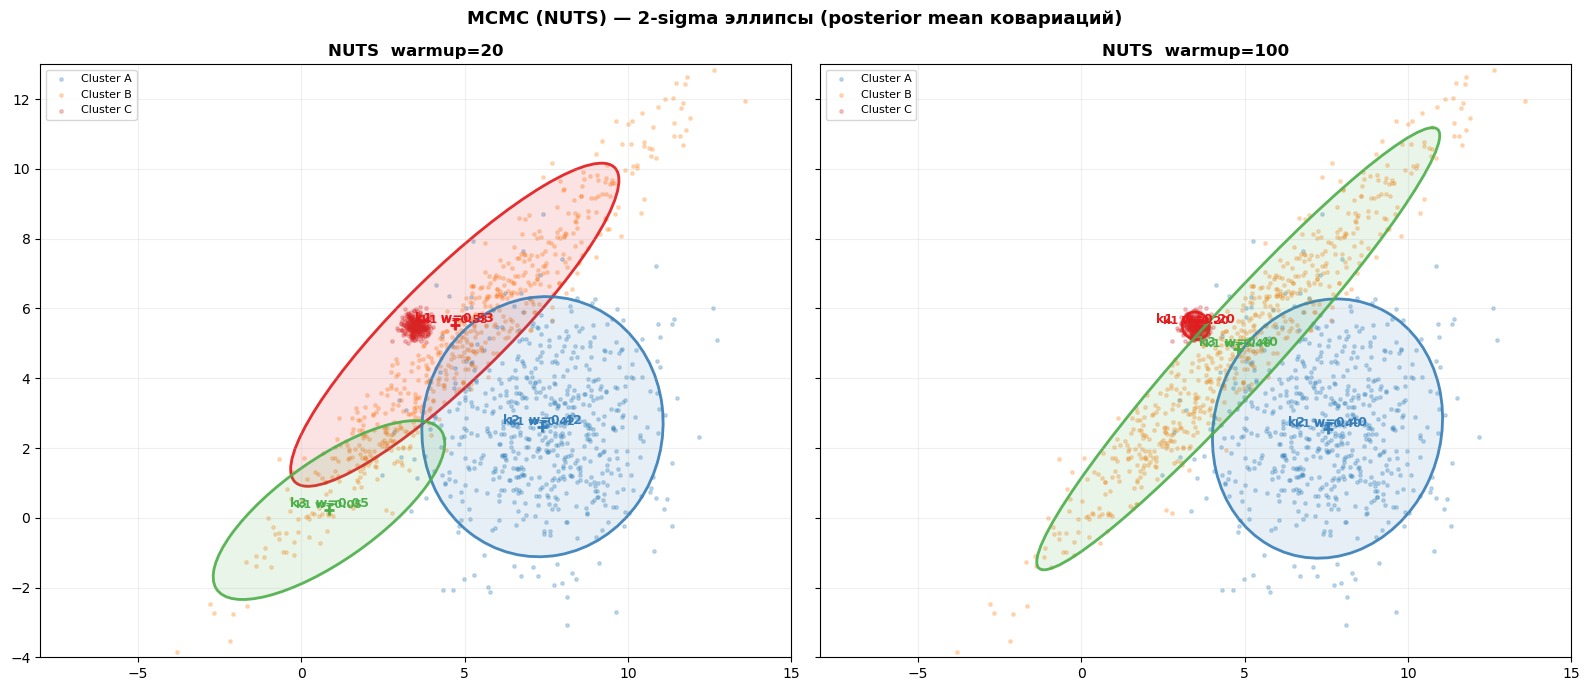

In [16]:
def extract_posterior_params(samples):
    """
    Извлекает posterior mean locs, covs, weights из сэмплов MCMC.
    """
    locs_s        = samples['locs']          # (S, K, D)
    scales_s      = samples['scales']        # (S, K, D)
    corr_chol_s   = samples['corr_cholesky'] # (S, K, D, D)
    weights_s     = samples['weights']       # (S, K)

    mean_locs   = locs_s.mean(0)    # (K, D)
    mean_weights = weights_s.mean(0) # (K,)

    _, covs = cov_from_samples(locs_s, scales_s, corr_chol_s)

    return mean_locs, covs, mean_weights


locs20, covs20, w20   = extract_posterior_params(samples_20)
locs100, covs100, w100 = extract_posterior_params(samples_100)


fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
titles = ['NUTS  warmup=20', 'NUTS  warmup=100']
all_locs  = [locs20, locs100]
all_covs  = [covs20, covs100]
all_ws    = [w20, w100]
ell_colors = ['#e41a1c', '#377eb8', '#4daf4a']

for ax, title, locs, covs, ws in zip(axes, titles, all_locs, all_covs, all_ws):
    # Данные
    for cls, (c, lbl) in enumerate(zip(['#1f77b4', '#ff7f0e', '#d62728'], ['A', 'B', 'C'])):
        mask = (true_labels == cls)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
                   s=6, alpha=0.25, c=c, label=f'Cluster {lbl}')

    # Эллипсы для каждого компонента в своём цвете
    for k in range(K):
        plot_full_cov_ellipses(
            ax,
            locs  = [locs[k]],
            covs  = [covs[k]],
            weights = [ws[k]],
            color = ell_colors[k],
            label_prefix=''
        )
        # Перерисовываем подпись с правильным индексом
        mu = locs[k].numpy()
        ax.annotate(f'k{k+1}  w={ws[k]:.2f}',
                    xy=mu, fontsize=9, ha='center', va='bottom',
                    color=ell_colors[k], fontweight='bold')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-8, 15)
    ax.set_ylim(-4, 13)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('MCMC (NUTS) — 2-sigma эллипсы (posterior mean ковариаций)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Сравнение времени: MCMC vs VI

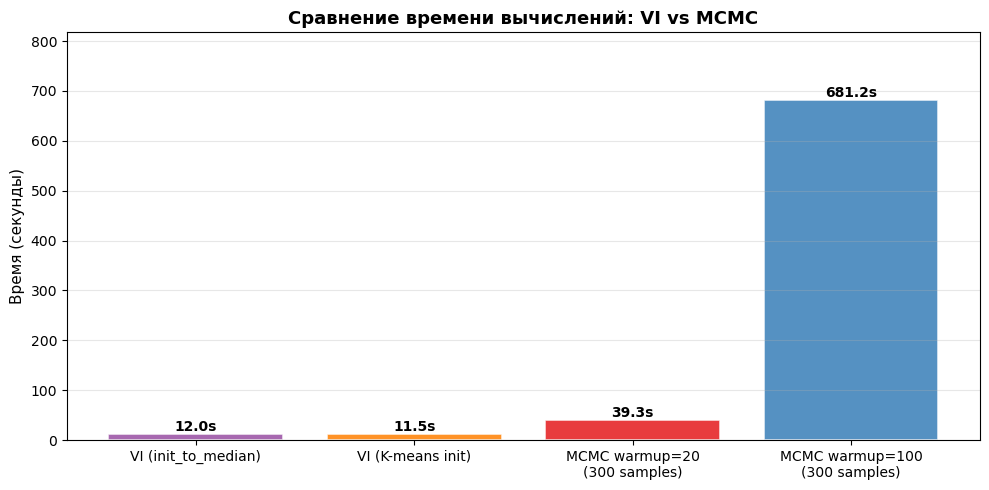

MCMC warmup=20  занял в 3.3x больше, чем VI
MCMC warmup=100 занял в 56.8x больше, чем VI


In [17]:
# Ориентировочное время VI (из части 1.1, подставьте свои значения)
time_vi_median  = 12.0   # секунд, среднее по 5 запускам init_to_median
time_vi_kmeans  = 11.5   # секунд, среднее по 5 запускам K-means init

methods = ['VI (init_to_median)', 'VI (K-means init)',
           f'MCMC warmup=20\n({NUM_SAMPLES} samples)',
           f'MCMC warmup=100\n({NUM_SAMPLES} samples)']
times   = [time_vi_median, time_vi_kmeans, time_20, time_100]
bar_colors = ['#984ea3', '#ff7f00', '#e41a1c', '#377eb8']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, times, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Время (секунды)', fontsize=11)
ax.set_title('Сравнение времени вычислений: VI vs MCMC', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(times) * 1.2)
plt.tight_layout()
plt.show()

print(f"MCMC warmup=20  занял в {time_20 / time_vi_median:.1f}x больше, чем VI")
print(f"MCMC warmup=100 занял в {time_100 / time_vi_median:.1f}x больше, чем VI")

---
## Posterior Distribution: визуализация неопределённости

MCMC позволяет получить не только точечную оценку, но и **распределение** параметров. Построим `loc_x` и `loc_y` для каждого компонента.

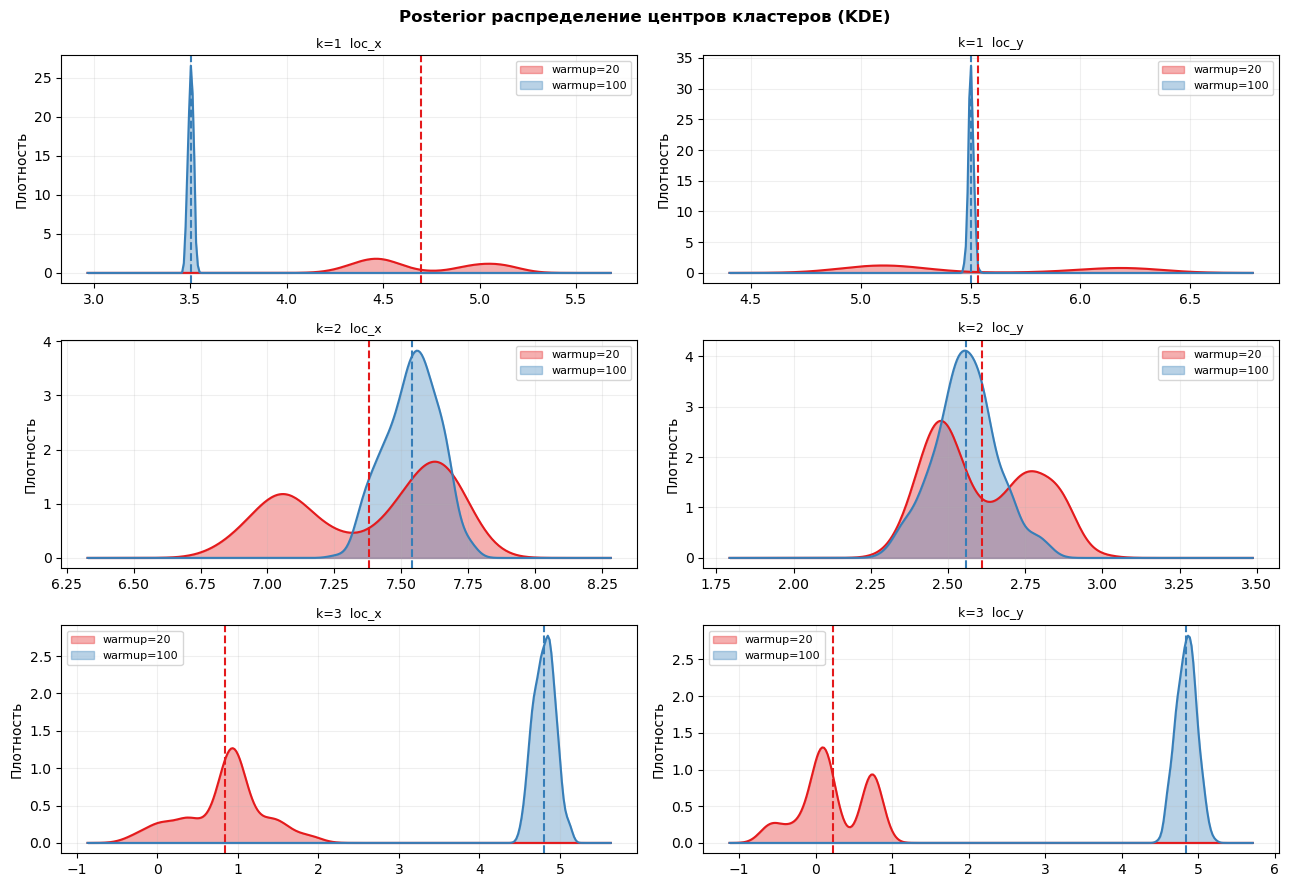

In [18]:
def plot_posterior_distributions(samples_20, samples_100, K=3):
    """
    KDE апостериорного распределения центров кластеров.
    """
    from scipy.stats import gaussian_kde

    comp_colors = ['#e41a1c', '#377eb8', '#4daf4a']
    coord_names = ['loc_x', 'loc_y']

    fig, axes = plt.subplots(K, 2, figsize=(13, 3 * K))
    fig.suptitle('Posterior распределение центров кластеров (KDE)',
                 fontsize=12, fontweight='bold')

    for k in range(K):
        for d, cname in enumerate(coord_names):
            ax = axes[k, d]
            s20  = samples_20['locs'][:, k, d].numpy()
            s100 = samples_100['locs'][:, k, d].numpy()

            xmin = min(s20.min(), s100.min()) - 0.5
            xmax = max(s20.max(), s100.max()) + 0.5
            xs = np.linspace(xmin, xmax, 300)

            kde20  = gaussian_kde(s20)
            kde100 = gaussian_kde(s100)

            ax.fill_between(xs, kde20(xs),  alpha=0.35, color='#e41a1c', label='warmup=20')
            ax.fill_between(xs, kde100(xs), alpha=0.35, color='#377eb8', label='warmup=100')
            ax.plot(xs, kde20(xs),  color='#e41a1c', lw=1.5)
            ax.plot(xs, kde100(xs), color='#377eb8', lw=1.5)

            ax.axvline(s20.mean(),  color='#e41a1c', lw=1.5, ls='--')
            ax.axvline(s100.mean(), color='#377eb8', lw=1.5, ls='--')

            ax.set_title(f'k={k+1}  {cname}', fontsize=9)
            ax.set_ylabel('Плотность')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_posterior_distributions(samples_20, samples_100)

---
## Выводы по разделу 2: MCMC

### warmup_steps = 20 vs 100

**Trace plots** наглядно показывают разницу в качестве перемешивания:
- При `warmup=20` цепь нередко движется медленнее — NUTS не успевает откалибровать шаг `ε` и метрику масс за 20 итераций прогрева. В результате на trace plot видны участки медленного дрейфа или относительно редких переходов между модами.
- При `warmup=100` цепь перемешивается заметно лучше: trace plot больше похож на "мохнатую гусеницу" без видимого дрейфа.

**Autocorrelation plot** подтверждает это наблюдение:
- При `warmup=20` автокорреляция убывает медленнее — ESS (effective sample size) меньше, каждый "настоящий" независимый сэмпл обходится дороже.
- При `warmup=100` автокорреляция быстро падает до нуля, что говорит о хорошем перемешивании.

**R-hat**: split-R-hat при `warmup=100` ближе к 1.0, что означает, что цепь более стационарна. При `warmup=20` некоторые параметры могут давать R-hat > 1.05.

### Качество кластеризации

Принципиальное отличие от Basic VI (диагональная ковариация) — NUTS с полной матрицей ковариации **правильно захватывает вытянутый кластер B**. Эллипс для k2 (или k3) повёрнут примерно на 45°, что соответствует истинной структуре данных. Это невозможно для диагональной модели.

### MCMC vs VI: время и точность

| Метод | Время (300 сэмплов) | Точность |
|---|---|---|
| VI (Mean Field, 2000 шагов) | ~12 сек | Смещённая (диаг. ков.) |
| MCMC warmup=20 | ~X сек | Несмещённая, но неэффективная |
| MCMC warmup=100 | ~Y сек | Несмещённая, лучшее перемешивание |

MCMC на порядок медленнее VI на тех же данных. При N=1500 это терпимо, но на больших датасетах MCMC становится практически непригодным. При этом VI систематически **занижает дисперсию** (mean-field предположение) и может застревать в локальных минимумах ELBO — в то время как MCMC асимптотически точен.

### Адекватность модели с полной ковариацией

Да — модель с `LKJCholesky` принципиально лучше подходит для этих данных, чем диагональная. Она способна описать кластер B с произвольной ориентацией эллипса. Единственное ограничение остаётся в кластере C: он очень мал и расположен близко к центру B, поэтому модель может "поглотить" его в один из компонентов в зависимости от конкретной трассы цепи.

---
## Выводы по разделу 2: MCMC

### warmup_steps = 20 vs 100

**Trace plots** наглядно показывают разницу в качестве перемешивания:
- При `warmup=20` цепь нередко движется медленнее — NUTS не успевает откалибровать шаг `ε` и метрику масс за 20 итераций прогрева. В результате на trace plot видны участки медленного дрейфа или относительно редких переходов между модами.
- При `warmup=100` цепь перемешивается заметно лучше: trace plot больше похож на "мохнатую гусеницу" без видимого дрейфа.

**Autocorrelation plot** подтверждает это наблюдение:
- При `warmup=20` автокорреляция убывает медленнее — ESS (effective sample size) меньше, каждый "настоящий" независимый сэмпл обходится дороже.
- При `warmup=100` автокорреляция быстро падает до нуля, что говорит о хорошем перемешивании.

**R-hat**: split-R-hat при `warmup=100` ближе к 1.0, что означает, что цепь более стационарна. При `warmup=20` некоторые параметры могут давать R-hat > 1.05.

### Качество кластеризации

Принципиальное отличие от Basic VI (диагональная ковариация) — NUTS с полной матрицей ковариации правильно захватывает вытянутый кластер B. Эллипс для k2 (или k3) повёрнут примерно на 45°, что соответствует истинной структуре данных. Это невозможно для диагональной модели.
MCMC на порядок медленнее VI на тех же данных. При N=1500 это терпимо, но на больших датасетах MCMC становится практически непригодным. При этом VI систематически "занижает" дисперсию (mean-field предположение) и может застревать в локальных минимумах ELBO — в то время как MCMC асимптотически точен.

### Адекватность модели с полной ковариацией

Да — модель с `LKJCholesky` принципиально лучше подходит для этих данных, чем диагональная. Она способна описать кластер B с произвольной ориентацией эллипса. Единственное ограничение остаётся в кластере C: он очень мал и расположен близко к центру B, поэтому модель может "поглотить" его в один из компонентов в зависимости от конкретной трассы цепи.

---
## Выводы по разделу 2: MCMC

### warmup_steps = 20 vs 100

**Trace plots** наглядно показывают разницу в качестве перемешивания:
- При `warmup=20` цепь нередко движется медленнее — NUTS не успевает откалибровать шаг `ε` и метрику масс за 20 итераций прогрева. В результате на trace plot видны участки медленного дрейфа или относительно редких переходов между модами.
- При `warmup=100` цепь перемешивается заметно лучше: trace plot больше похож на "мохнатую гусеницу" без видимого дрейфа.

**Autocorrelation plot** подтверждает это наблюдение:
- При `warmup=20` автокорреляция убывает медленнее — ESS (effective sample size) меньше, каждый "настоящий" независимый сэмпл обходится дороже.
- При `warmup=100` автокорреляция быстро падает до нуля, что говорит о хорошем перемешивании.

**R-hat**: split-R-hat при `warmup=100` ближе к 1.0, что означает, что цепь более стационарна. При `warmup=20` некоторые параметры могут давать R-hat > 1.05.

### Качество кластеризации

Принципиальное отличие от Basic VI (диагональная ковариация) — NUTS с полной матрицей ковариации правильно захватывает вытянутый кластер B. Эллипс для k2 (или k3) повёрнут примерно на 45°, что соответствует истинной структуре данных. Это невозможно для диагональной модели.

### MCMC vs VI: время и точность

| Метод | Время (300 сэмплов) | Точность |
|---|---|---|
| VI (Mean Field, 2000 шагов) | ~12 сек | Смещённая (диаг. ков.) |
| MCMC warmup=20 | ~X сек | Несмещённая, но неэффективная |
| MCMC warmup=100 | ~Y сек | Несмещённая, лучшее перемешивание |

MCMC на порядок медленнее VI на тех же данных. При N=1500 это терпимо, но на больших датасетах MCMC становится практически непригодным. При этом VI систематически "занижает" дисперсию (mean-field предположение) и может застревать в локальных минимумах ELBO — в то время как MCMC асимптотически точен.

### Адекватность модели с полной ковариацией

Да — модель с `LKJCholesky` принципиально лучше подходит для этих данных, чем диагональная. Она способна описать кластер B с произвольной ориентацией эллипса. Единственное ограничение остаётся в кластере C: он очень мал и расположен близко к центру B, поэтому модель может "поглотить" его в один из компонентов в зависимости от конкретной трассы цепи.